In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch


torch.manual_seed(10)

img_dir = '/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Separated_audio/'
df =  pd.read_csv('/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/label_cut_audio_new.csv', index_col=None)

df['label'].value_counts()

label
healthy        15479
symptomatic     3956
COVID-19        1201
Name: count, dtype: int64

In [7]:
df = df[df['label'].isin(['COVID-19', 'symptomatic'])]
df['label'].value_counts()

label
symptomatic    3956
COVID-19       1201
Name: count, dtype: int64

Look at the SNR of these files

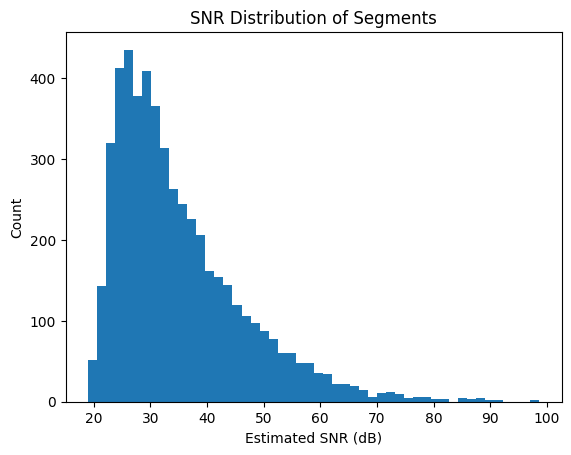

In [9]:
plt.hist(df['snr'], bins=50)
plt.xlabel("Estimated SNR (dB)")
plt.ylabel("Count")
plt.title("SNR Distribution of Segments")
plt.show()

Create Train/Test split and creation of melspectrograms

In [12]:
from sklearn.model_selection import train_test_split

# Split by UUIDs and labels
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=True, stratify=df['label'], random_state=10)

df_train.to_csv("/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/train_cut_label_covid_vs_symp.csv")
df_test.to_csv("/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/test_cut_label_covid_vs_symp.csv")

Create new folder

In [14]:
import shutil

dest = '/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Separated_audio_covid_vs_symp/'
src = '/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Separated_audio/'

# Create directories for train and test sets
for f in df['non_silent_name']:
    shutil.copy(src + f, dest + f)

In [18]:
import librosa
separated_audio = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Separated_audio_covid_vs_symp/"

len_signals=list()

for f in os.listdir(separated_audio):
    if f ==".DS_Store":
        continue
    signal, sr = librosa.load(separated_audio + f)
    len_signals.append(len(signal))

mean_signal_length = round(np.mean(len_signals))
print(mean_signal_length)
print(mean_signal_length/sr)

Python(51758) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


29193
1.3239455782312926


In [23]:
#Creation of MelSpec on the Test set (non-augmented)
from Scripts.spec_augment import MelSpecto

separated_audio = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Separated_audio_covid_vs_symp/"

labels_cut_audio_path = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/test_cut_label_covid_vs_symp.csv"
mels_path = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/MelSpecs_covid_vs_symp_test/"
melspec_labels_path = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/MelSpecs_labels_test_covid_vs_symp.csv"

mean_signal_length = int(29193 + sr*0.5) #Add half a second to the mean signal length

MelSpecto(waves_path = separated_audio,meanSignalLength=mean_signal_length + 1 ,labels_cut_audio_path= labels_cut_audio_path, mels_path =mels_path , melspec_labels_path = melspec_labels_path)

In [31]:
melspec_labels_path = pd.read_csv("/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/MelSpecs_labels_test_covid_vs_symp.csv")

MelSpecs_labels_test = pd.DataFrame(columns =['filename', 'label'])
label_dict  ={'COVID-19':1, 'symptomatic':0}
MelSpecs_labels_test['filename']=melspec_labels_path['cut_melspec']
MelSpecs_labels_test['label']=melspec_labels_path['status'].map(label_dict)

MelSpecs_labels_test.to_csv("/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/MelSpecs_labels_test_covid_vs_symp.csv")

In [33]:
melspec_labels_path = pd.read_csv("/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/train_cut_label_covid_vs_symp.csv")
melspec_labels_path['label'].value_counts()

label
symptomatic    3164
COVID-19        961
Name: count, dtype: int64

In [34]:
#Creation of Augmented MelSpec on the Train set (augmented)
from Scripts.pitch_shift import pitchShift_covid_modified

metaDataPath = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/train_cut_label_covid_vs_symp.csv"
audioDataPath = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Separated_audio_covid_vs_symp/"
augmentedSignals = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Pitch_Shift_covid_vs_symp_train/"

pitchShift_covid_modified(metaDataPath,
           audioDataPath,
           augmentedSignals)

12321.wav   100 / 4125
20468.wav   200 / 4125
16910.wav   300 / 4125
6611.wav   400 / 4125
4327.wav   500 / 4125
837.wav   600 / 4125
9736.wav   700 / 4125
4192.wav   800 / 4125
3701.wav   900 / 4125
8960.wav   1000 / 4125
12301.wav   1100 / 4125
3374.wav   1200 / 4125
11944.wav   1300 / 4125
3537.wav   1400 / 4125
241.wav   1500 / 4125
3109.wav   1600 / 4125
18415.wav   1700 / 4125
15289.wav   1800 / 4125
21335.wav   1900 / 4125
10267.wav   2000 / 4125
11942.wav   2100 / 4125
15480.wav   2200 / 4125
19973.wav   2300 / 4125
2195.wav   2400 / 4125
11610.wav   2500 / 4125
3390.wav   2600 / 4125
7145.wav   2700 / 4125
7732.wav   2800 / 4125
12019.wav   2900 / 4125
15621.wav   3000 / 4125
8319.wav   3100 / 4125
3252.wav   3200 / 4125
5986.wav   3300 / 4125
1385.wav   3400 / 4125
6700.wav   3500 / 4125
4651.wav   3600 / 4125
16911.wav   3700 / 4125
3427.wav   3800 / 4125
11939.wav   3900 / 4125
16550.wav   4000 / 4125
11666.wav   4100 / 4125


In [36]:
#Creation of Augmented MelSpec on the Train set (augmented)

from Scripts.spec_augment import SpectAugment

mean_signal_length = int(29193 + sr*0.5) #Add half a second to the mean signal length

# Filepath for augmented audio (original and pitch shifted audio): input
wavs_signal_augmented = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/Pitch_Shift_covid_vs_symp_train/"
files = os.listdir(wavs_signal_augmented)
files = [f for f in files if f.endswith('.wav')]

# Filepath for where to save melspectograms: output
augmentedData = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/MelSpecs_covid_vs_symp_train/"

# Filepath for where labels (0: no COVID, 1: COVID) for each melspectogram will be saved
labels_mels_signal_augmented = "/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/MelSpecs_labels_train_covid_vs_symp.csv"
SpectAugment(wavs_signal_augmented,
             files,
             20,
             augmentedData,
             labels_mels_signal_augmented,
             mean_signal_length)

Converting: |██████████████████████████████████████████████████| 100.0% 


In [37]:
melspec_labels_path = pd.read_csv("/Users/titouan/Desktop/HDA/Term_2/2-ML/Project/MelSpecs_labels_train_covid_vs_symp.csv")
melspec_labels_path

,filename,label
0,0.png,0
1,1.png,0
2,2.png,1
3,3.png,1
4,4.png,1
...,...,...
14972,14972.png,1
14973,14973.png,1
14974,14974.png,1
14975,14975.png,0
